# ⚽ Football Analytics with Python
## Chapter 9 — Scatter Plots and Peer Group Analysis

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-09-Scatter-Plots/Chapter_09_Scatter_Plots.ipynb)

---

A scatter plot places every player in a space defined by two metrics simultaneously.
Unlike a bar chart — which can only show one metric at a time — a scatter plot answers
the question: *"Where does this player sit when you measure two things at once?"*

This is where football analytics gets interesting. Most players are good at one thing.
The rare ones are good at two. A scatter plot shows you which is which — and it shows
you the whole peer group at once so you understand the context.

### What You Will Build

**Part 1:** Basic scatter — xA/90 vs Goals/90 with player labels
**Part 2:** Quadrant chart — dividing the space into analytical zones
**Part 3:** Focus player highlight — the glow halo technique
**Part 4:** xG overperformance scatter — above/below the diagonal line
**Part 5:** `build_scatter()` template — any two metrics, any players

### The Two Analytical Questions This Chapter Answers

> *"Is Marcus Silva a finisher, a creator, or both — and how does that compare
> to his peers?"*

> *"Which players are converting above their expected goals — and is that
> a pattern or just luck?"*

---
*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

In [1]:
!pip install pandas matplotlib numpy scipy --quiet
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy import stats
%matplotlib inline
plt.rcParams['figure.dpi']=150
print("✓ Ready.")

✓ Ready.


In [1]:
BG='#0d1117'; BG2='#0d1b2a'; BG3='#161b22'
WHITE='#f0f6fc'; GRAY='#8b949e'; GOLD='#EDBB00'
GREEN='#4CAF50'; YELLOW='#ffd60a'; ORANGE='#FF9800'; RED='#e63946'
TIER_COLORS={'Elite':GREEN,'Above Average':YELLOW,'Average':ORANGE,'Below Average':RED}
PLAYER_COLORS={'Marcus Silva':'#3498DB','Lucas Ferreira':'#2ecc71',
    'James Thornton':'#e74c3c','Diego Varela':'#9B59B6','Amir Hassan':'#FF9800',
    'Kai Becker':'#00BCD4','Tom Wheeler':'#F06292','Sam Okafor':'#80CBC4',
    'Elena Rossi':'#FFD54F','Carlos Mendez':'#CE93D8','Jin Park':'#A5D6A7'}
def style_axis(ax,theme='dark',xlabel=None,ylabel=None,title=None,subtitle=None):
    bg=BG if theme=='dark' else '#f8f9fa'
    tc=WHITE if theme=='dark' else '#1a1a2e'
    gc=WHITE if theme=='dark' else '#cccccc'
    sc=GRAY if theme=='dark' else '#888888'
    ax.set_facecolor(bg)
    ax.spines['bottom'].set_color(sc); ax.spines['left'].set_color(sc)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.tick_params(colors=tc,labelsize=10)
    ax.grid(True,alpha=0.07,color=gc,linewidth=0.8)
    if xlabel: ax.set_xlabel(xlabel,color=tc,fontsize=11,labelpad=8)
    if ylabel: ax.set_ylabel(ylabel,color=tc,fontsize=11,labelpad=8)
    if title and subtitle:
        ax.set_title(title+'\n'+subtitle,color=tc,fontsize=13,fontweight='bold',pad=15,linespacing=1.6)
    elif title: ax.set_title(title,color=tc,fontsize=13,fontweight='bold',pad=12)
    return ax
print("✓ Design system loaded.")

✓ Design system loaded.


In [1]:
df=pd.read_csv('data/chapter09_scatter.csv')
print(df[['player','goals_per90','assists_per90','xg_per90','xa_per90','overperformance','tier']].to_string(index=False))

        player  goals_per90  assists_per90  xg_per90  xa_per90  overperformance          tier
  Marcus Silva         0.54           0.33      0.41      0.27             0.13         Elite
Lucas Ferreira         0.31           0.44      0.28      0.41             0.03         Elite
James Thornton         0.48           0.31      0.36      0.30             0.12         Elite
  Diego Varela         0.48           0.22      0.44      0.21             0.04 Above Average
   Amir Hassan         0.34           0.43      0.28      0.38             0.06         Elite
    Kai Becker         0.35           0.29      0.32      0.29             0.03 Above Average
   Tom Wheeler         0.31           0.45      0.28      0.42             0.03         Elite
    Sam Okafor         0.12           0.32      0.29      0.39            -0.17       Average
   Elena Rossi         0.29           0.23      0.28      0.24             0.01       Average
 Carlos Mendez         0.50           0.22      0.40      0.

---
## Part 1 — Basic Scatter: Two Metrics, Every Player

The most basic scatter: xA/90 (assists quality) on the X axis, Goals/90 on the Y axis. Every player is a dot. The dot's position tells you both numbers simultaneously.

**X axis = creation. Y axis = finishing.** Top-right = dual threat. Top-left = pure finisher. Bottom-right = pure creator.

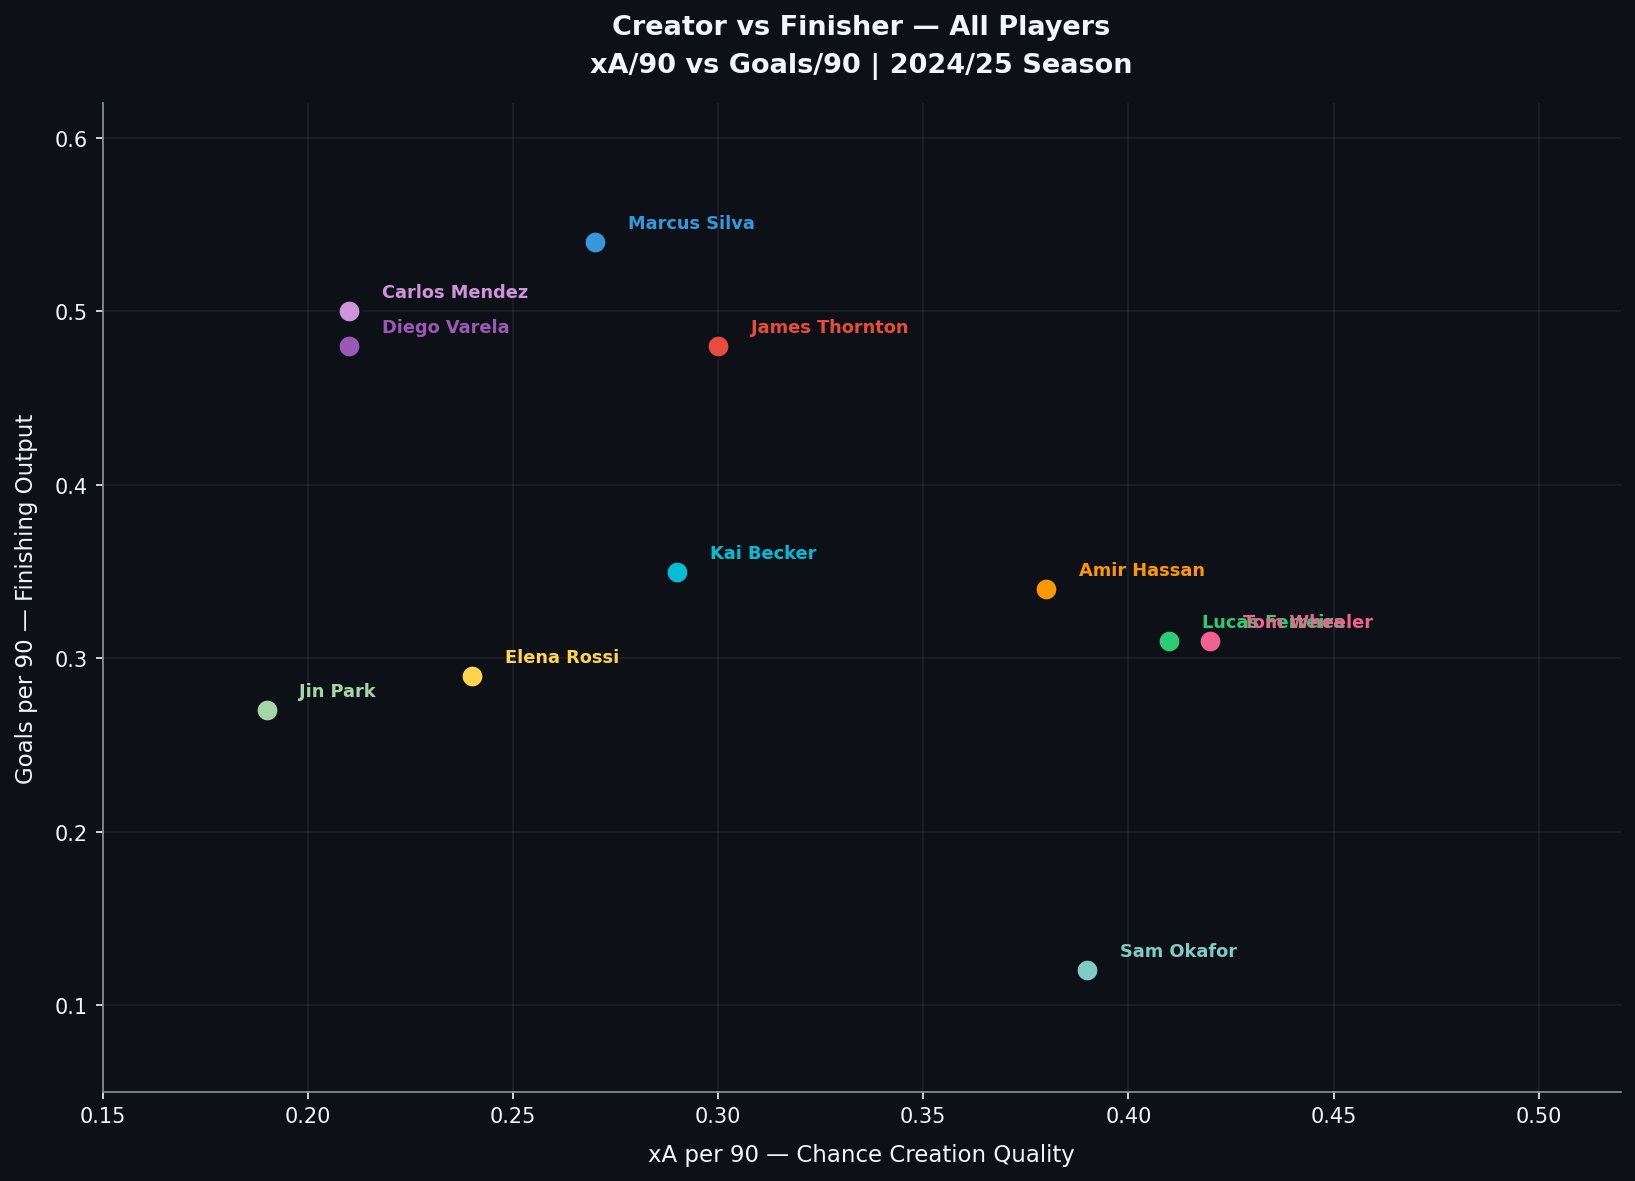

In [1]:
df = pd.read_csv('data/chapter09_scatter.csv')

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(BG)

for _, row in df.iterrows():
    c = PLAYER_COLORS.get(row['player'], GRAY)

    # Draw the dot
    ax.scatter(row['xa_per90'], row['goals_per90'],
               s=120, color=c, zorder=4,
               edgecolors=BG, linewidth=1.5)

    # Label next to the dot
    ax.annotate(row['player'],
                xy=(row['xa_per90'], row['goals_per90']),
                xytext=(row['xa_per90'] + 0.008, row['goals_per90'] + 0.008),
                color=c, fontsize=8.5, fontweight='bold', zorder=5)

style_axis(ax,
    xlabel='xA per 90 — Chance Creation Quality',
    ylabel='Goals per 90 — Finishing Output',
    title='Creator vs Finisher — All Players',
    subtitle='xA/90 vs Goals/90 | 2024/25 Season')

ax.set_xlim(0.15, 0.52)
ax.set_ylim(0.05, 0.62)
plt.tight_layout()
plt.show()

---
## Part 2 — Quadrant Chart

Divide the scatter into four zones using the group average as the threshold. Now every player's dot has a zone label — dual threat, pure finisher, pure creator, limited output.

In [1]:
# Add quadrant lines at the group averages
avg_xa  = df['xa_per90'].mean()
avg_gls = df['goals_per90'].mean()

print(f"Group average xA/90:    {avg_xa:.3f}")
print(f"Group average Goals/90: {avg_gls:.3f}")
print()
print("Quadrant thresholds: players above/right of lines are above average")

Group average xA/90:    0.301
Group average Goals/90: 0.363

Quadrant thresholds: players above/right of lines are above average


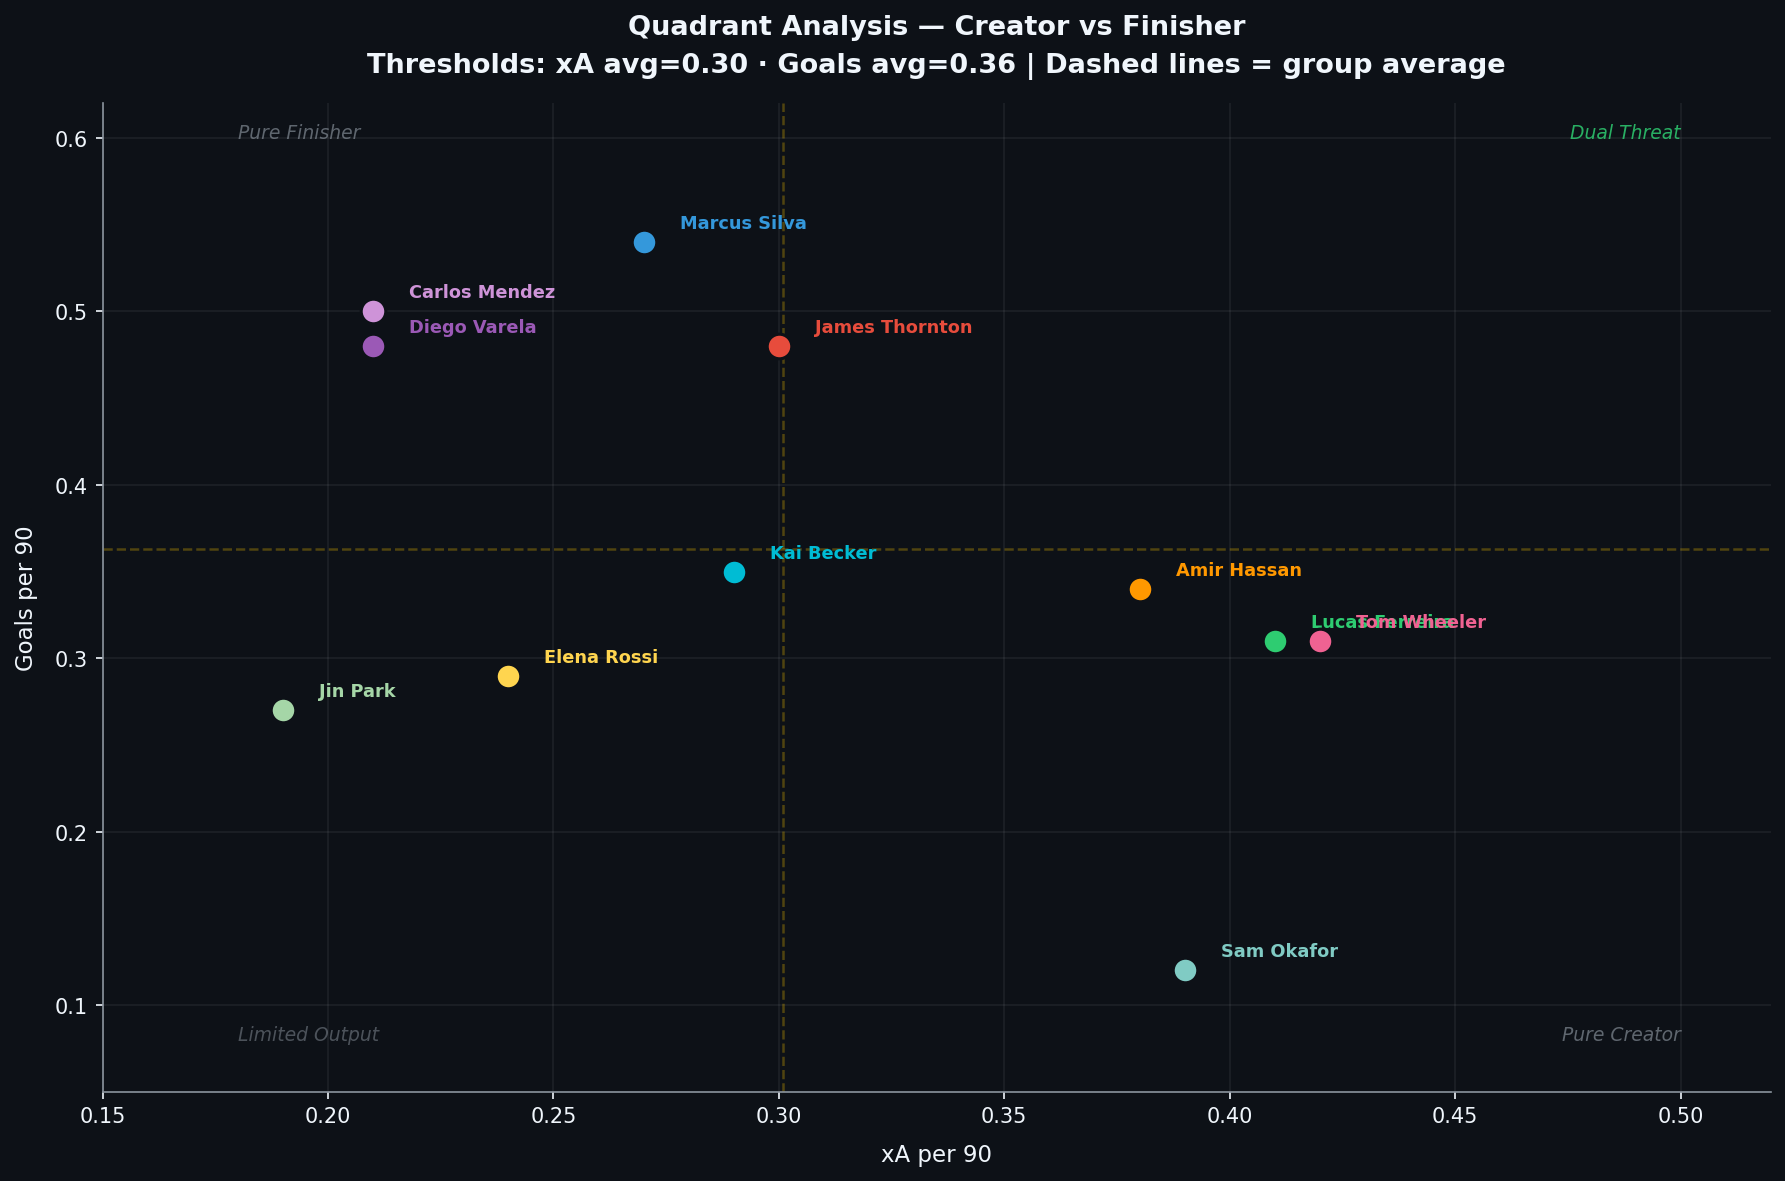


Player quadrant assignments:
  Marcus Silva         → Pure Finisher
  Lucas Ferreira       → Pure Creator
  James Thornton       → Pure Finisher
  Diego Varela         → Pure Finisher
  Amir Hassan          → Pure Creator
  Kai Becker           → Limited Output
  Tom Wheeler          → Pure Creator
  Sam Okafor           → Pure Creator
  Elena Rossi          → Limited Output
  Carlos Mendez        → Pure Finisher
  Jin Park             → Limited Output


In [1]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG)

# Quadrant dividing lines
ax.axvline(x=avg_xa,  color=GOLD, linestyle='--', alpha=0.30, linewidth=1.2)
ax.axhline(y=avg_gls, color=GOLD, linestyle='--', alpha=0.30, linewidth=1.2)

# Quadrant labels — positioned in each corner
ax.text(0.50, 0.60, 'Dual Threat',    color='#2ecc71', fontsize=9, style='italic', ha='right', alpha=0.85)
ax.text(0.18, 0.60, 'Pure Finisher',  color=GRAY,      fontsize=9, style='italic', alpha=0.65)
ax.text(0.50, 0.08, 'Pure Creator',   color=GRAY,      fontsize=9, style='italic', ha='right', alpha=0.65)
ax.text(0.18, 0.08, 'Limited Output', color=GRAY,      fontsize=9, style='italic', alpha=0.50)

for _, row in df.iterrows():
    c = PLAYER_COLORS.get(row['player'], GRAY)
    ax.scatter(row['xa_per90'], row['goals_per90'],
               s=140, color=c, zorder=4, edgecolors=BG, linewidth=1.5)
    ax.annotate(row['player'],
                xy=(row['xa_per90'], row['goals_per90']),
                xytext=(row['xa_per90']+0.008, row['goals_per90']+0.008),
                color=c, fontsize=8.5, fontweight='bold')

style_axis(ax, xlabel='xA per 90', ylabel='Goals per 90',
           title='Quadrant Analysis — Creator vs Finisher',
           subtitle=f'Dashed lines = group average | xA avg={avg_xa:.2f} · Goals avg={avg_gls:.2f}')
ax.set_xlim(0.15, 0.52); ax.set_ylim(0.05, 0.62)
plt.tight_layout()
plt.show()

# Print which quadrant each player is in
print("\nPlayer quadrant assignments:")
for _, row in df.iterrows():
    horiz = 'High Creation' if row['xa_per90']  >= avg_xa  else 'Low Creation'
    vert  = 'High Goals'    if row['goals_per90']>= avg_gls else 'Low Goals'
    quad  = 'Dual Threat' if horiz=='High Creation' and vert=='High Goals' else \
            'Pure Finisher' if horiz=='Low Creation' and vert=='High Goals' else \
            'Pure Creator'  if horiz=='High Creation' and vert=='Low Goals' else 'Limited Output'
    print(f"  {row['player']:<20} → {quad}")

---
## Part 3 — The Glow Halo: Highlighting Focus Players

When you have two players to compare against a peer group, you need them to stand out immediately. The glow halo technique uses three concentric scatter calls at decreasing opacity to create a radiant effect. The peers fade to background. The focus players command attention.

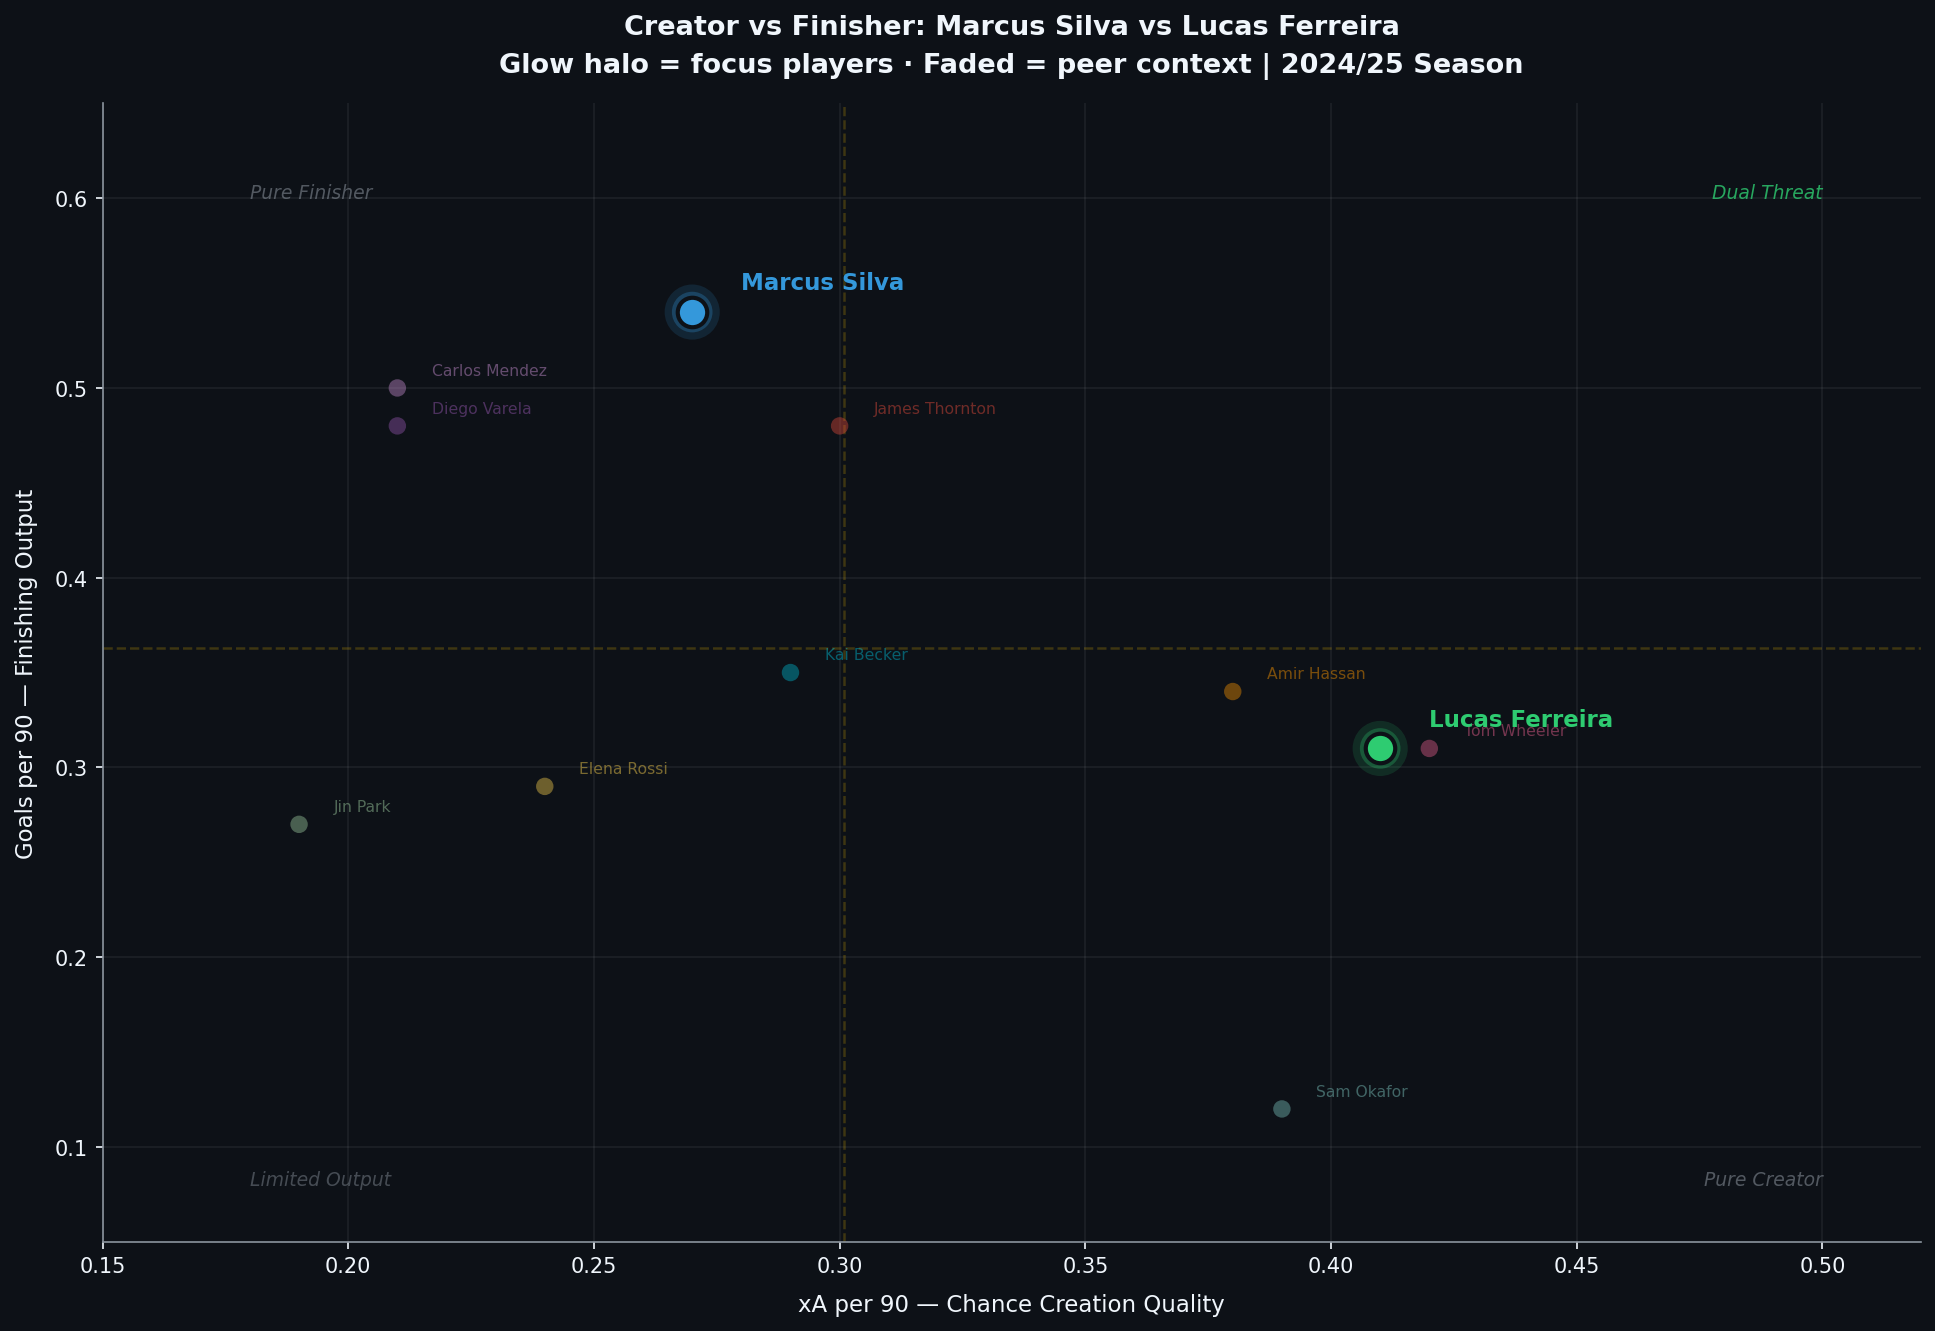

The glow halo uses 3 scatter() calls per focus player:
  s=700, alpha=0.15 — outer glow
  s=380, alpha=0.28 — mid ring
  s=200, alpha=1.00 — solid core
  Each call uses zorder=5, 6, 7 to layer correctly.


In [1]:
FOCUS_PLAYERS = {'Marcus Silva', 'Lucas Ferreira'}

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor(BG)

# Quadrant lines
ax.axvline(x=avg_xa,  color=GOLD, linestyle='--', alpha=0.22, linewidth=1.2)
ax.axhline(y=avg_gls, color=GOLD, linestyle='--', alpha=0.22, linewidth=1.2)
ax.text(0.50, 0.60, 'Dual Threat',    color='#2ecc71', fontsize=9, style='italic', ha='right', alpha=0.80)
ax.text(0.18, 0.60, 'Pure Finisher',  color=GRAY, fontsize=9, style='italic', alpha=0.55)
ax.text(0.50, 0.08, 'Pure Creator',   color=GRAY, fontsize=9, style='italic', ha='right', alpha=0.55)
ax.text(0.18, 0.08, 'Limited Output', color=GRAY, fontsize=9, style='italic', alpha=0.45)

# Step 1: Draw peer players first — small, faded, behind everything
for _, row in df.iterrows():
    if row['player'] in FOCUS_PLAYERS: continue
    c = PLAYER_COLORS.get(row['player'], GRAY)
    ax.scatter(row['xa_per90'], row['goals_per90'],
               s=70, color=c, alpha=0.40, zorder=3, edgecolors='none')
    ax.annotate(row['player'],
                xy=(row['xa_per90'], row['goals_per90']),
                xytext=(row['xa_per90']+0.007, row['goals_per90']+0.007),
                color=c, alpha=0.45, fontsize=7.5)

# Step 2: Draw focus players — three concentric circles = glow halo
for player in ['Marcus Silva', 'Lucas Ferreira']:
    row = df[df['player'] == player].iloc[0]
    c   = PLAYER_COLORS[player]

    # Outer glow (large, very transparent)
    ax.scatter(row['xa_per90'], row['goals_per90'],
               s=700, color=c, alpha=0.15, zorder=5, edgecolors='none')
    # Mid glow (medium, semi-transparent)
    ax.scatter(row['xa_per90'], row['goals_per90'],
               s=380, color=c, alpha=0.28, zorder=6, edgecolors='none')
    # Core dot (small, fully opaque)
    ax.scatter(row['xa_per90'], row['goals_per90'],
               s=200, color=c, alpha=1.0, zorder=7,
               edgecolors=BG, linewidth=2.0)

    ax.annotate(player,
                xy=(row['xa_per90'], row['goals_per90']),
                xytext=(row['xa_per90']+0.010, row['goals_per90']+0.012),
                color=c, fontsize=11, fontweight='bold', zorder=8)

style_axis(ax,
    xlabel='xA per 90 — Chance Creation Quality',
    ylabel='Goals per 90 — Finishing Output',
    title='Creator vs Finisher: Marcus Silva vs Lucas Ferreira',
    subtitle='Glow halo = focus players · Faded = peer context | 2024/25 Season')
ax.set_xlim(0.15, 0.52)
ax.set_ylim(0.05, 0.65)
plt.tight_layout()
plt.show()

print("The glow halo uses 3 scatter() calls per focus player:")
print("  s=700, alpha=0.15 — outer glow")
print("  s=380, alpha=0.28 — mid ring")
print("  s=200, alpha=1.00 — solid core")
print("Each call uses zorder=5, 6, 7 to layer correctly.")

---
## Part 4 — xG Overperformance: The Diagonal Line

Plot xG/90 on X and Goals/90 on Y. Draw the diagonal line where they are equal (x=y). Players above the line score more than their xG predicts — they are overperforming. Players below score less. The diagonal is the axis of honesty.

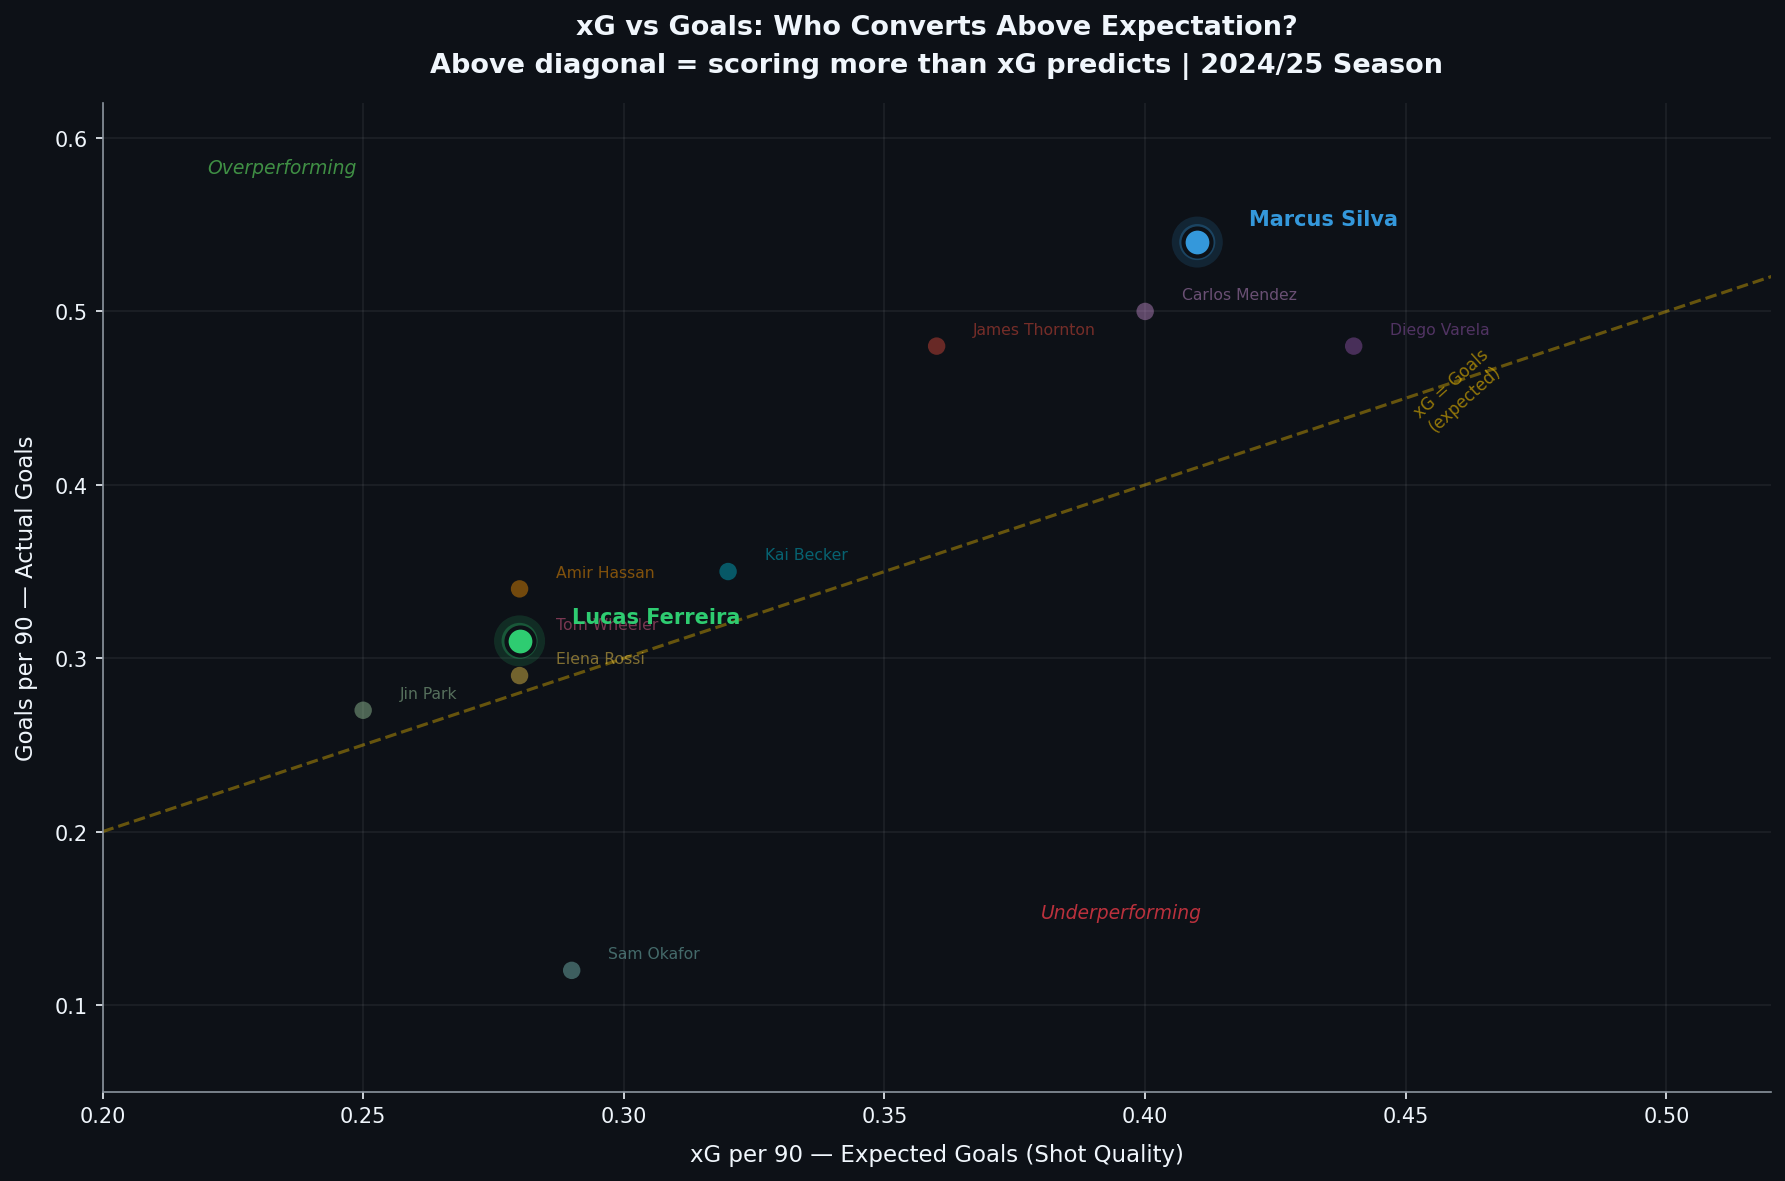


Overperformance summary (Goals/90 - xG/90):
  Marcus Silva         +0.13  █████████████▲
  James Thornton       +0.12  ████████████▲
  Carlos Mendez        +0.10  ██████████▲
  Amir Hassan          +0.06  ██████▲
  Diego Varela         +0.04  ████▲
  Lucas Ferreira       +0.03  ███▲
  Kai Becker           +0.03  ███▲
  Tom Wheeler          +0.03  ███▲
  Jin Park             +0.02  ██▲
  Elena Rossi          +0.01  █▲
  Sam Okafor           -0.17  █████████████████▼


In [1]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG)

# The diagonal line: y = x (where actual goals = expected goals)
x_line = np.linspace(0.20, 0.55, 200)
ax.plot(x_line, x_line,
        color=GOLD, linewidth=1.5, linestyle='--', alpha=0.40, zorder=2)
ax.text(0.46, 0.43, 'xG = Goals\n(expected)',
        color=GOLD, fontsize=8, alpha=0.60, rotation=42, ha='center')

# Above/below labels
ax.text(0.22, 0.58, 'Overperforming', color=GREEN, fontsize=9, style='italic', alpha=0.80)
ax.text(0.38, 0.15, 'Underperforming', color=RED,   fontsize=9, style='italic', alpha=0.80)

FOCUS_PLAYERS = {'Marcus Silva', 'Lucas Ferreira'}

for _, row in df.iterrows():
    c        = PLAYER_COLORS.get(row['player'], GRAY)
    is_focus = row['player'] in FOCUS_PLAYERS

    if is_focus:
        # Glow halo for focus players
        ax.scatter(row['xg_per90'], row['goals_per90'], s=600, color=c, alpha=0.15, zorder=5, edgecolors='none')
        ax.scatter(row['xg_per90'], row['goals_per90'], s=300, color=c, alpha=0.28, zorder=6, edgecolors='none')
        ax.scatter(row['xg_per90'], row['goals_per90'], s=180, color=c, alpha=1.0,  zorder=7, edgecolors=BG, linewidth=2.0)
        ax.annotate(row['player'], xy=(row['xg_per90'], row['goals_per90']),
                    xytext=(row['xg_per90']+0.010, row['goals_per90']+0.010),
                    color=c, fontsize=10, fontweight='bold', zorder=8)
    else:
        ax.scatter(row['xg_per90'], row['goals_per90'], s=70, color=c, alpha=0.42, zorder=3, edgecolors='none')
        ax.annotate(row['player'], xy=(row['xg_per90'], row['goals_per90']),
                    xytext=(row['xg_per90']+0.007, row['goals_per90']+0.007),
                    color=c, alpha=0.48, fontsize=7.5)

style_axis(ax,
    xlabel='xG per 90 — Expected Goals (Shot Quality)',
    ylabel='Goals per 90 — Actual Goals',
    title='xG vs Goals: Who Converts Above Expectation?',
    subtitle='Above diagonal = scoring more than xG predicts | 2024/25 Season')
ax.set_xlim(0.20, 0.52); ax.set_ylim(0.05, 0.62)
plt.tight_layout()
plt.show()

# Print overperformance table
print("\nOverperformance summary (Goals/90 - xG/90):")
df_sorted = df.sort_values('overperformance', ascending=False)
for _, row in df_sorted.iterrows():
    bar = '█' * int(abs(row['overperformance'])*100) + ('▲' if row['overperformance']>0 else '▼')
    print(f"  {row['player']:<20} {row['overperformance']:+.2f}  {bar}")

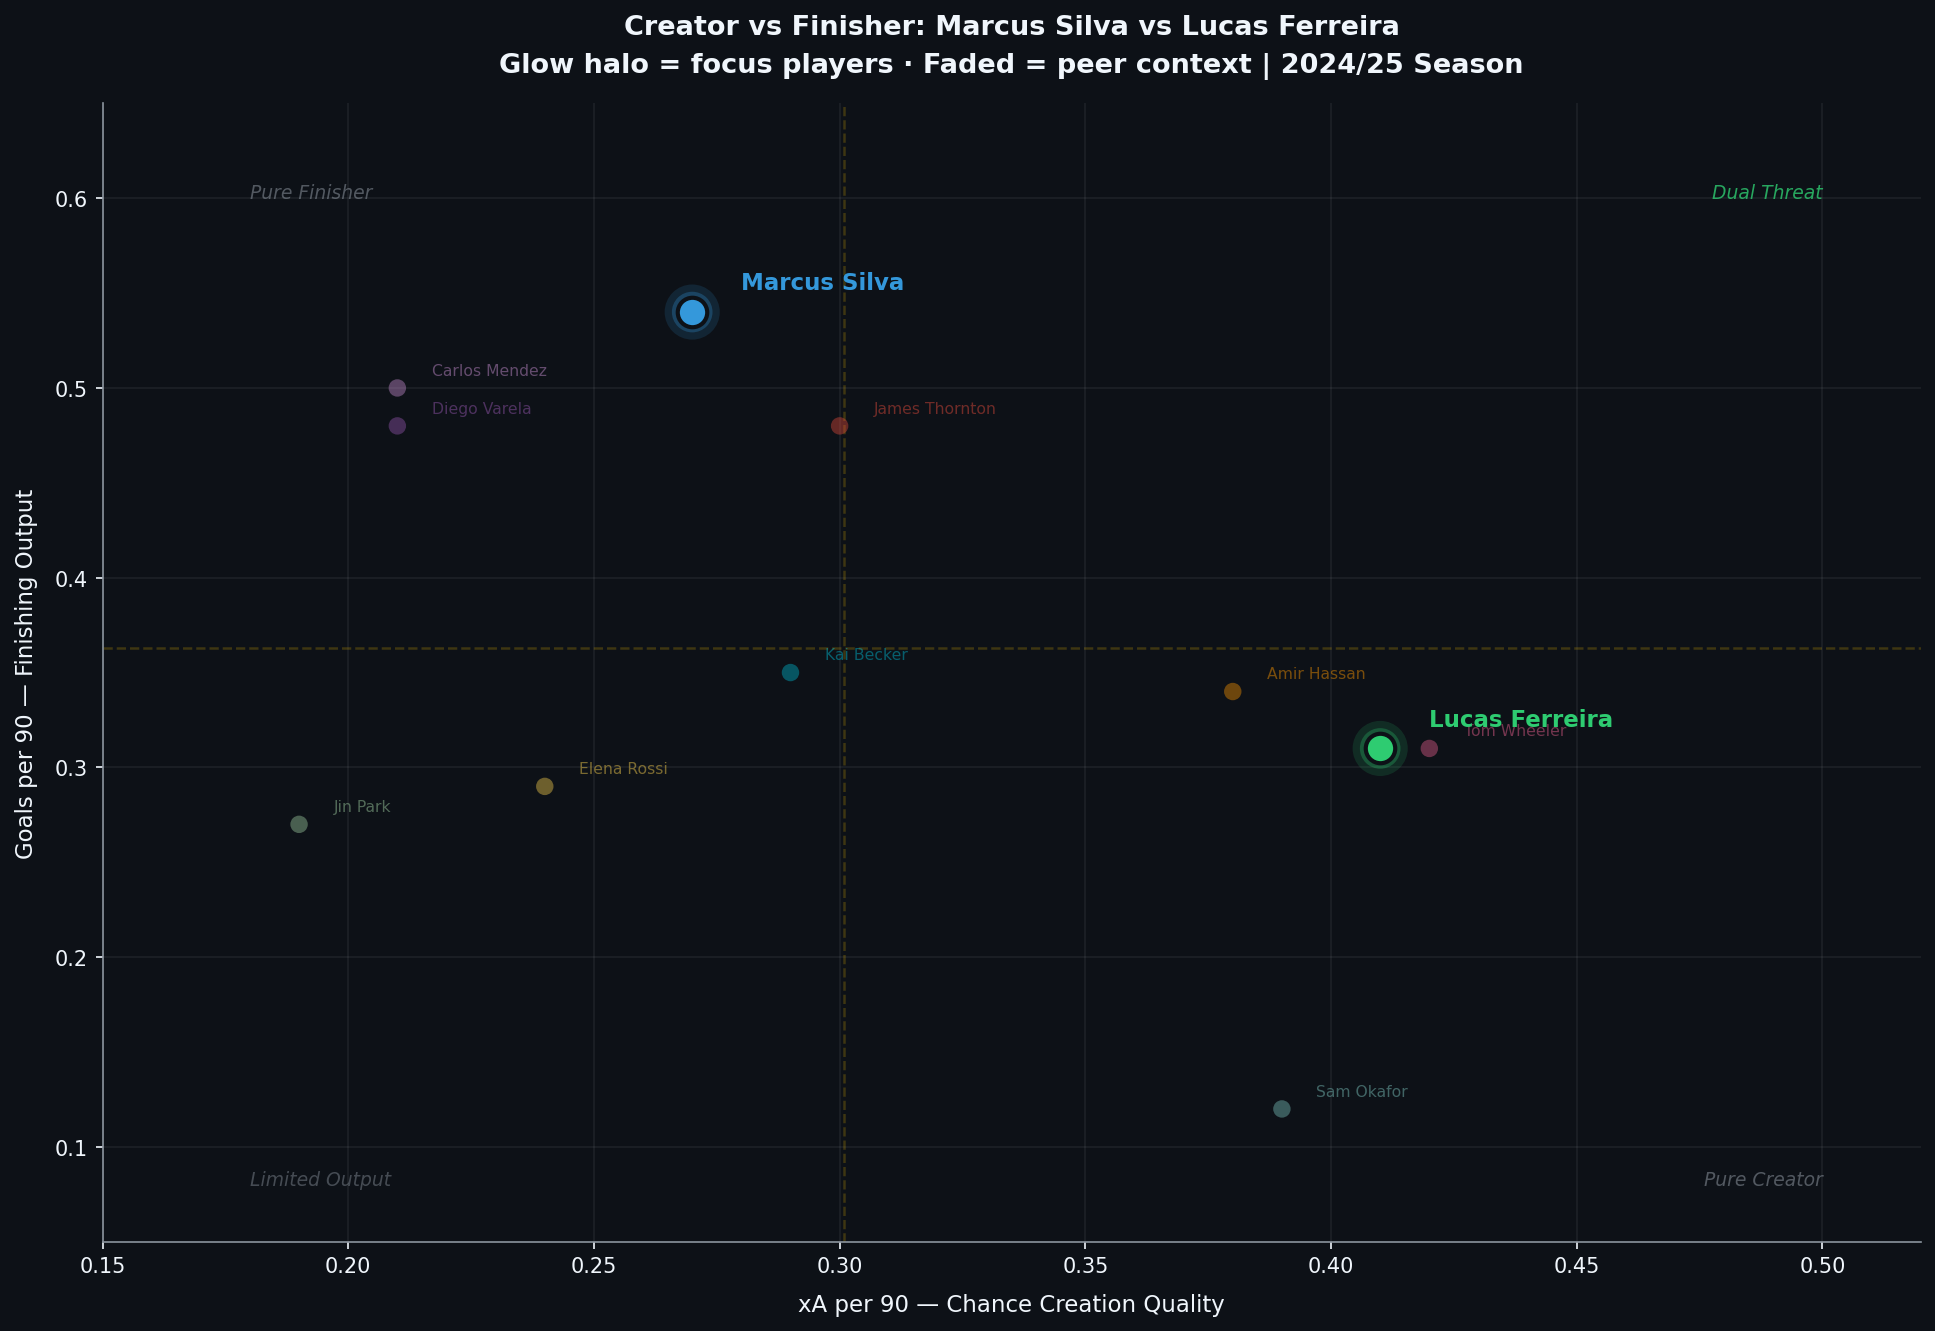

✓ build_scatter() template working.


In [1]:
# THE REUSABLE TEMPLATE
def build_scatter(df, x_col, y_col, focus_players=None,
                  show_quadrants=True, diagonal_line=False,
                  title='', subtitle='', xlim=None, ylim=None,
                  figsize=(12, 8)):
    """
    Build a professional scatter plot with optional quadrants, diagonal,
    and focus player glow halos.

    Parameters
    ----------
    df             : DataFrame
    x_col          : str — column for X axis
    y_col          : str — column for Y axis
    focus_players  : set[str] — players to highlight with glow halo
    show_quadrants : bool — draw group average threshold lines
    diagonal_line  : bool — draw y=x diagonal (for xG vs Goals)
    title, subtitle: str
    xlim, ylim     : tuple — axis limits
    figsize        : tuple

    Returns: fig, ax
    """
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(BG)
    focus_players = focus_players or set()

    if show_quadrants:
        ax_avg = df[x_col].mean()
        ay_avg = df[y_col].mean()
        ax.axvline(x=ax_avg, color=GOLD, linestyle='--', alpha=0.22, linewidth=1.2)
        ax.axhline(y=ay_avg, color=GOLD, linestyle='--', alpha=0.22, linewidth=1.2)

    if diagonal_line:
        lo = min(df[x_col].min(), df[y_col].min()) * 0.9
        hi = max(df[x_col].max(), df[y_col].max()) * 1.1
        xl = np.linspace(lo, hi, 200)
        ax.plot(xl, xl, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.38)

    for _, row in df.iterrows():
        c = PLAYER_COLORS.get(row['player'], GRAY)
        x, y = row[x_col], row[y_col]
        if row['player'] in focus_players:
            ax.scatter(x, y, s=600, color=c, alpha=0.15, zorder=5, edgecolors='none')
            ax.scatter(x, y, s=300, color=c, alpha=0.28, zorder=6, edgecolors='none')
            ax.scatter(x, y, s=180, color=c, alpha=1.0,  zorder=7, edgecolors=BG, linewidth=2.0)
            ax.annotate(row['player'], xy=(x,y), xytext=(x+0.008,y+0.008),
                        color=c, fontsize=10, fontweight='bold', zorder=8)
        else:
            ax.scatter(x, y, s=70, color=c, alpha=0.40, zorder=3, edgecolors='none')
            ax.annotate(row['player'], xy=(x,y), xytext=(x+0.007,y+0.007),
                        color=c, alpha=0.45, fontsize=7.5)

    style_axis(ax, xlabel=x_col.replace('_',' ').title(),
               ylabel=y_col.replace('_',' ').title(),
               title=title, subtitle=subtitle)
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)
    return fig, ax

# Test — shots vs goals
fig, ax = build_scatter(
    df, x_col='shots_per90', y_col='goals_per90',
    focus_players={'Marcus Silva','Diego Varela'},
    show_quadrants=True,
    title='Shots vs Goals per 90',
    subtitle='Do more shots always mean more goals?',
    xlim=(2.3, 4.6), ylim=(0.05, 0.62)
)
plt.tight_layout()
plt.show()
print("✓ build_scatter() template working.")

---
## Exercises

### Exercise 1 (Easy) — Different Axes
Call `build_scatter()` with `x_col='pass_accuracy_pct'` and `y_col='keyp_per90'`.
Does better passing accuracy lead to more key passes? What does the scatter tell you?

### Exercise 2 (Medium) — Annotate a Specific Player
After `build_scatter()` returns `fig, ax`, add a custom callout box for Marcus Silva:
```python
ax.annotate('Best dual-threat\nin the group',
    xy=(silva_xa, silva_goals), xytext=(silva_xa+0.05, silva_goals+0.05),
    color=PLAYER_COLORS['Marcus Silva'], fontsize=8,
    arrowprops=dict(arrowstyle='->', color=PLAYER_COLORS['Marcus Silva'], lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor=BG, edgecolor=PLAYER_COLORS['Marcus Silva']))
```

### Exercise 3 (Hard) — Four-Player Focus
Modify `build_scatter()` to accept a `focus_players` list where each entry also specifies
a label offset: `[('Marcus Silva', 0.01, 0.01), ('Diego Varela', -0.05, 0.01)]`.
This allows labels to be placed differently for each focus player to avoid overlap.

---
## Chapter Summary

| Concept | What You Learned |
|---------|-----------------|
| `ax.scatter()` | Basic scatter plot — s=size, alpha=opacity |
| Quadrant chart | `ax.axvline()` + `ax.axhline()` at group averages |
| Glow halo | Three concentric scatter calls at s=600/380/180 |
| `zorder` | Controls layer order — higher = drawn on top |
| Diagonal line | `y=x` reference for expected vs actual comparisons |
| `build_scatter()` | Template — any two metrics, any focus players |

---
*© 2026 HackrLife Media LLC · BarcaFutbol Analytics Course*